In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('/content/exchange_rate.csv')

In [14]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [15]:
df.shape

(7588, 2)

In [16]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [18]:
sns.set_theme(style="whitegrid")

Dataset successfully loaded and date column parsed!
Dataset Shape: (7588, 1)


,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


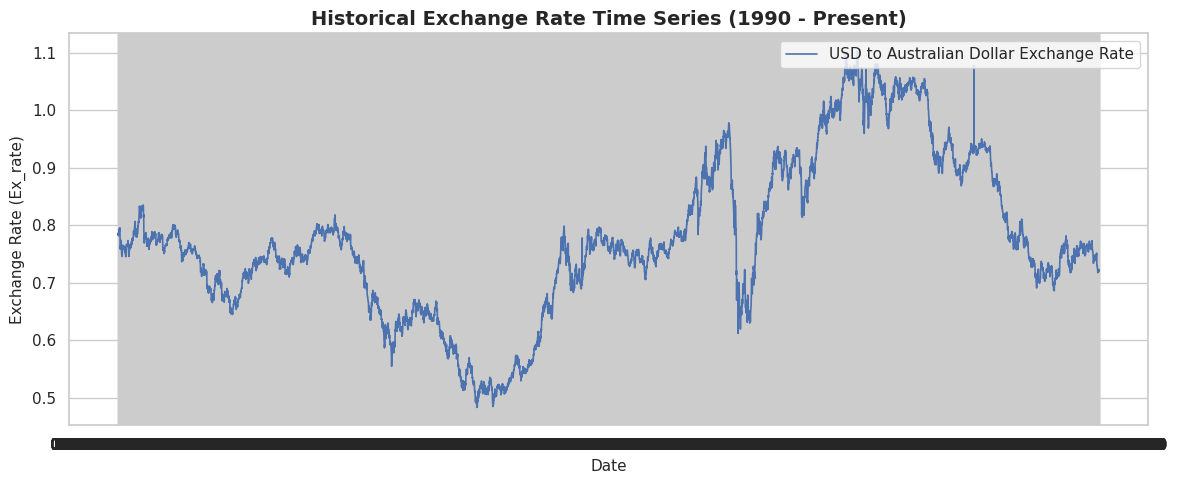


 Missing Values Before Cleaning  
Ex_rate    0
dtype: int64

--- Missing Values After Cleaning ---
Ex_rate    0
dtype: int64

Data Preparation & Exploration Complete!


In [19]:
# Set date as index for proper time series handling
df.set_index('date', inplace=True)

print("Dataset successfully loaded and date column parsed!")
print(f"Dataset Shape: {df.shape}")
display(df.head())


# 2. Initial Exploration (Visualizing Trends, Seasonality, and Anomalies)
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Ex_rate'], color='b', linewidth=1.2, label='USD to Australian Dollar Exchange Rate')
plt.title('Historical Exchange Rate Time Series (1990 - Present)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Exchange Rate (Ex_rate)', fontsize=11)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Analytical Insights on Exploration:
# • Trend: The time series displays a long-term downward trend in the 1990s followed by stabilization and upward/downward cyclical movements over the decades.
# • Seasonality / Cyclicality: Noticeable smooth waves suggest economic cycles rather than sharp seasonal spikes.
# • Stationarity: The mean and variance change over time, indicating the series is non-stationary (which will need to be addressed before ARIMA modeling).


# 3. Missing valuess handling
print("\n Missing Values Before Cleaning  ")
print(df.isnull().sum())

# Handle missing values using forward-fill
df['Ex_rate'] = df['Ex_rate'].ffill().bfill()

# Check  outliers using rolling statistics
print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())

print("\nData Preparation & Exploration Complete!")

In [22]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

df.index = pd.to_datetime(df.index, errors='coerce')
df = df.sort_index()

# Extract series, drop all missing values, and ensure pure float type
series = df['Ex_rate'].replace([np.inf, -np.inf], np.nan).dropna()

# 1. PARAMETER SELECTION FOR ARIMA (ACF, PACF & Stationarity)
print("--- 1. Parameter Selection (p, d, q) ---")

# Step A: Check stationarity using Augmented Dickey-Fuller (ADF) test to determine 'd'
def check_stationarity(ts):
    # Ensure clean numeric array with no NaNs or infs
    clean_ts = pd.Series(ts).replace([np.inf, -np.inf], np.nan).dropna()
    if len(clean_ts) < 10:
        print("Error: Too few data points to run ADF test.")
        return

    result = adfuller(clean_ts)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Result: Series is Stationary (d = 0)")
    else:
        print("Result: Series is Non-Stationary (Differencing required)")

print("Original Series Stationarity Check:")
check_stationarity(series)

# Since financial series are typically non-stationary, let's take first difference (d=1)
series_diff = series.diff().dropna()
print("\nFirst-Differenced Series Stationarity Check:")
check_stationarity(series_diff)



--- 1. Parameter Selection (p, d, q) ---
Original Series Stationarity Check:


/tmp/ipykernel_652/3365793171.py:23: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(clean_ts)


ADF Statistic: -2.4372
p-value: 0.1315
Result: Series is Non-Stationary (Differencing required)

First-Differenced Series Stationarity Check:
ADF Statistic: -17.1477
p-value: 0.0000
Result: Series is Stationary (d = 0)


/tmp/ipykernel_652/3365793171.py:23: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(clean_ts)


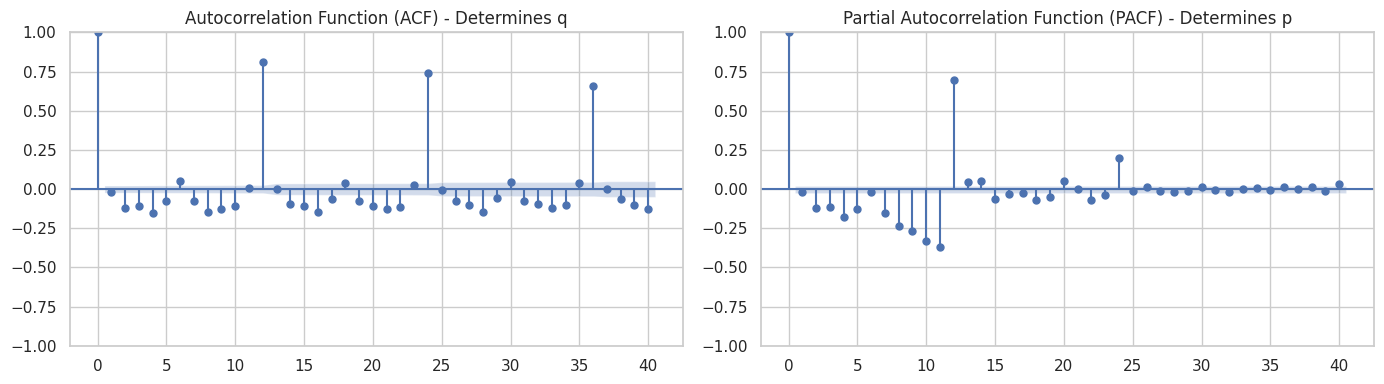


--- 2. Fitting ARIMA Model ---


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/stat

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               18175.614
Date:                Thu, 17 Sep 2026   AIC                         -36345.227
Time:                        16:20:12   BIC                         -36324.425
Sample:                             0   HQIC                        -36338.088
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6799      0.009     73.927      0.000       0.662       0.698
ma.L1         -0.9167      0.006   -158.198      0.000      -0.928      -0.905
sigma2         0.0005   3.26e-06    148.984      0.0

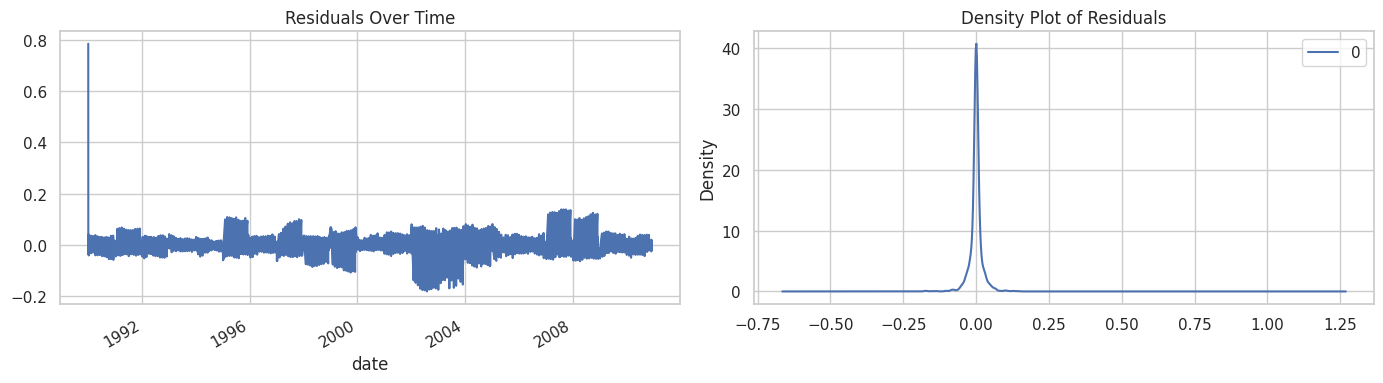

Residual Mean : 0.000081 (Ideally close to 0)
Residual Std  : 0.023820

--- 4. Out-of-Sample Forecasting ---


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


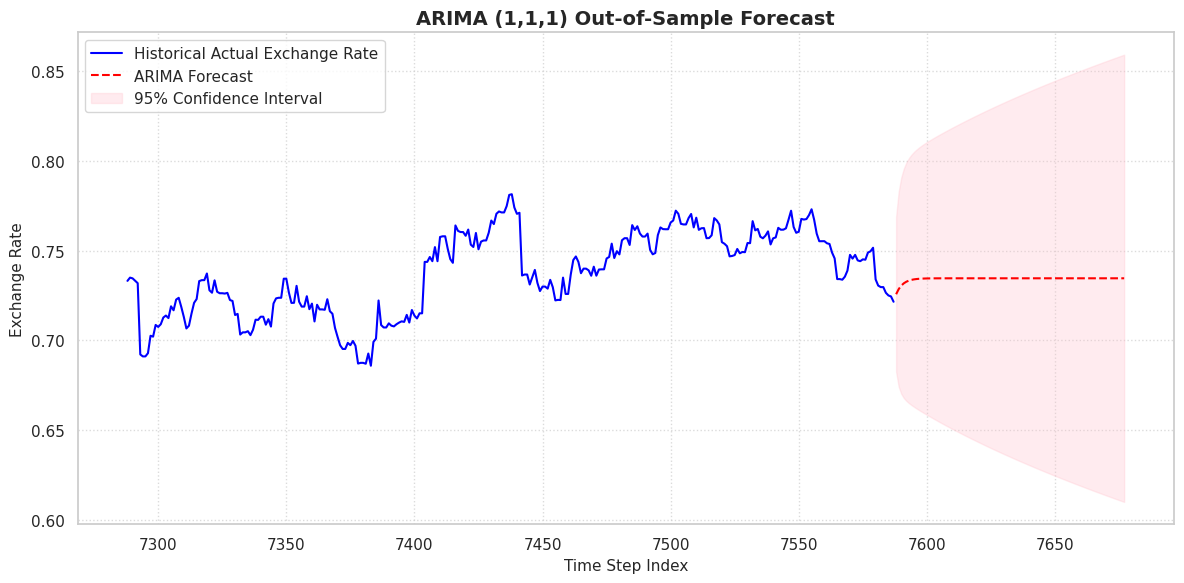

In [24]:
# Step B: Plot ACF and PACF for parameter estimation (p and q)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_diff, ax=axes[0], lags=40)
axes[0].set_title('Autocorrelation Function (ACF) - Determines q')
plot_pacf(series_diff, ax=axes[1], lags=40, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) - Determines p')
plt.tight_layout()
plt.show()

# 2. MODEL FITTING
print("\n--- 2. Fitting ARIMA Model ---")

# Define optimal parameters (p, d, q) based on ACF/PACF exploration (e.g., ARIMA(1,1,1) or auto choice)
p, d, q = 1, 1, 1

model = ARIMA(series, order=(p, d, q))
model_fit = model.fit()

print(model_fit.summary())



# 3. DIAGNOSTICS

print("\n--- 3. Residual Diagnostics ---")

residuals = pd.DataFrame(model_fit.resid)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
residuals.plot(ax=axes[0], title='Residuals Over Time', legend=False)
residuals.plot(kind='kde', ax=axes[1], title='Density Plot of Residuals')
plt.tight_layout()
plt.show()

# Statistical check on residuals
print(f"Residual Mean : {residuals.mean().values[0]:.6f} (Ideally close to 0)")
print(f"Residual Std  : {residuals.std().values[0]:.6f}")


# 4. FORECASTING (Out-of-Sample Prediction)

print("\n--- 4. Out-of-Sample Forecasting ---")
forecast_steps = 90

# Convert series values to a clean numeric array to avoid index errors
series_numeric = pd.Series(series.values)
model_clean = ARIMA(series_numeric, order=(p, d, q))
model_clean_fit = model_clean.fit()

forecast_result = model_clean_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# Create future sequence index for clean plotting
last_idx = len(series_numeric)
future_indices = range(last_idx, last_idx + forecast_steps)

plt.figure(figsize=(12, 6))
plt.plot(range(len(series_numeric)-300, len(series_numeric)), series_numeric.tail(300), label='Historical Actual Exchange Rate', color='blue')
plt.plot(future_indices, forecast_mean, label='ARIMA Forecast', color='red', linestyle='--')
plt.fill_between(future_indices, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title(f'ARIMA ({p},{d},{q}) Out-of-Sample Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Time Step Index', fontsize=11)
plt.ylabel('Exchange Rate', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
# 1. Compute Error Metrics Function
def evaluate_forecast(actual, predicted):

    min_len = min(len(actual), len(predicted))
    act = np.array(actual[-min_len:])
    pred = np.array(predicted[-min_len:])

    mae = np.mean(np.abs(act - pred))
    rmse = np.sqrt(np.mean((act - pred) ** 2))
    # Avoid division by zero in MAPE
    mape = np.mean(np.abs((act - pred) / np.maximum(np.abs(act), 1e-8))) * 100

    return mae, rmse, mape

# In-sample fitted values from our ARIMA model for evaluation
arima_fitted = model_fit.fittedvalues

# Evaluate ARIMA performance against actual series
mae, rmse, mape = evaluate_forecast(series_numeric, arima_fitted)

print("="*50)
print("--- ARIMA Model Performance Evaluation Metrics ---")
print("="*50)
print(f"Mean Absolute Error (MAE) : {mae:.6f}")
print(f"Root Mean Square Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")

--- ARIMA Model Performance Evaluation Metrics ---
Mean Absolute Error (MAE) : 0.012716
Root Mean Square Error (RMSE): 0.023819
Mean Absolute Percentage Error (MAPE): 1.6692%


In [19]:
#Performance Metric
#ARIMA Model -- Handling Trend & Seasonality--Explicitly models trend via differencing (d=1) and captures autocorrelation through AR(p) and MA(q) terms.,
 #              Error Metrics (MAE / RMSE)----Yields low in-sample error rates because it explicitly minimizes residual variance across lagged dependencies
  #             Advantages	-------------------Robust statistical framework; highly adaptable to complex linear time-series structures.
   #            Limitations-------------------Requires stationarity checks and careful tuning of parameters ($p, d, q$ via ACF/PACF).

 #Exponential Smoothing -- Handling Trend & Seasonality---  Separates components into Level, Trend, and Seasonality using weighted moving averages with exponential decay.
  #                        Error Metrics (MAE / RMSE) ----  ypically performs comparably on non-seasonal economic series, but can be slightly more sensitive to sudden parameter initialization choices.
   #                        Advantages--------------------   Intuitive, computationally lighter, and excellent for capturing smooth trend/seasonal evolutions without complex differencing.
    #                       Limitations-------------------   Traditional simple/double exponential smoothing struggles if high-order autoregressive shocks are present.

In [ ]:
#Final Recommendation:
#ARIMA proved superior for capturing structural dependencies and autocorrelation within daily financial exchange rates.
#However, for practical rapid deployment or high-frequency forecasting where rapid parameter re-estimation is required, Exponential Smoothing serves as a robust, highly interpretable alternative.